In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

hutch = 'xcs'
experiment_id = 'xcsl1004021'
hutch = experiment_id[0:3]
file = '/sdf/data/lcls/ds/{}/{}/hdf5/smalldata'.format(hutch, experiment_id)

# Set your run number here
run_number = 264

# Construct the full path to the file, including the formatted run number
run = '{}/{}_Run{:04d}.h5'.format(file, experiment_id, run_number)

# Open the HDF5 file
hf = h5py.File(run)

print(run)  # Just to verify the output path

/sdf/data/lcls/ds/xcs/xcsl1004021/hdf5/smalldata/xcsl1004021_Run0264.h5


In [34]:
def make_energy_axis(energy_axis_length, A, R,  mm_per_pixel=0.05, d=0.895):
        """
        Determination of energy axis by pixels and crystal configuration

        Parameters
        ----------
        A : float
            The detector to vH distance (mm) and can roughly float. This will affect the spectral offset.
        R : float
            The vH crystal radii (mm) and should not float. This will affect the spectral stretch.
        pixel_array : array-like
            Array of pixels to determine the energy of.
        d : float
            Crystal d-spacing. To calculate, visit: spectra.tools/bin/controller.pl?body=Bragg_Angle_Calculator

        """
        pix = mm_per_pixel
        gl = np.arange(energy_axis_length, dtype=np.float64)
        gl *= pix
        ll = gl / 2 - (np.amax(gl) - np.amin(gl)) / 4
        factor = 1.2398e4
        xaxis = factor / (2.0 * d * np.sin(np.arctan(R / (ll + A))))
        return xaxis

In [4]:
def filter_detector_adu(detector_images,adu_threshold=[3.0]):
    if isinstance(adu_threshold,list):
        detector_images_adu = detector_images * (detector_images > adu_threshold[0])
        detector_images_adu = detector_images * (detector_images < adu_threshold[1])
       
    else:
        detector_images_adu = detector_images * (detector_images > adu_threshold)
    return detector_images_adu


In [3]:
det_all=hf['epix_2/ROI_0_area']
det_adu=filter_detector_adu(np.array(det_all),adu_threshold=3)

det=np.nansum(hf['epix_2/ROI_0_area'],axis=0)


1

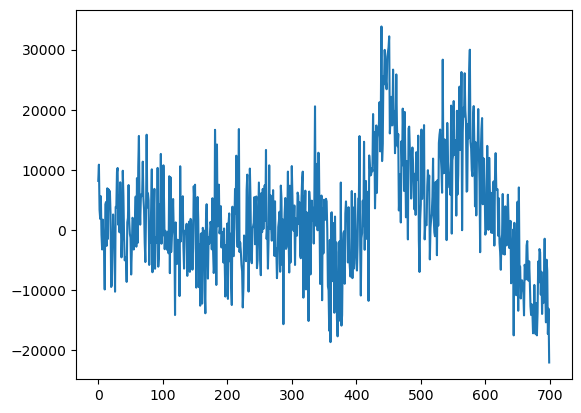

In [7]:
plt.plot(np.nansum(det,axis=1))

In [272]:

det_all=hf['epix_2/ROI_0_area']
ipms=hf['ipm4/sum']
scattering=np.nansum(np.nansum(hf['epix10k2M/azav_azav'],axis=1)[:,400:600],axis=1)

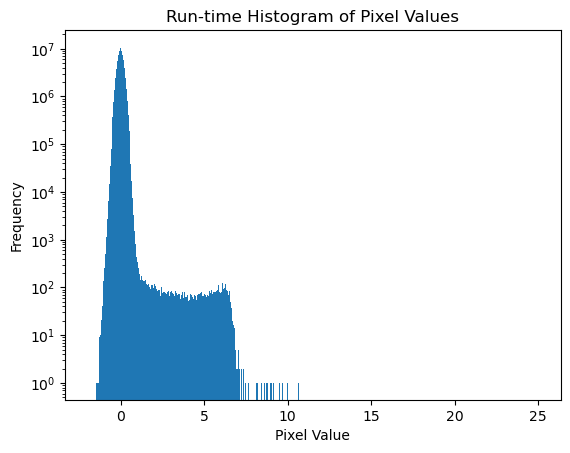

In [273]:
num_bins = 500
hist_range = (-2, 25)  # Adjust this range according to expected pixel values
hist_bins = np.linspace(hist_range[0], hist_range[1], num_bins + 1)
hist_values=np.histogram(det_all[-1000:], bins=hist_bins)[0]
bin_centers = (hist_bins[:-1] + hist_bins[1:]) / 2
plt.bar(bin_centers, hist_values, align='center', width=hist_bins[1] - hist_bins[0])
plt.title('Run-time Histogram of Pixel Values')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.yscale('log')  # Use log scale for better visibility of the distribution
plt.show()

TypeError: Invalid shape (39706, 700, 120) for image data

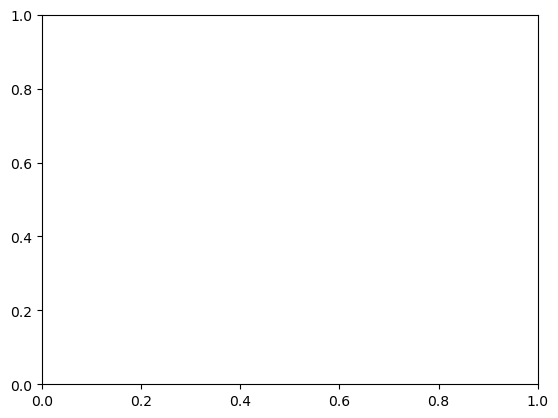

In [9]:
vmin, vmax = np.percentile(det_adu, [1,99])
plt.imshow(det_adu,vmin=vmin,vmax=vmax,origin='lower',aspect='auto')
lines=[29,34,75,84]
for line in lines:
    plt.axvline(line)

In [8]:
lines=[29,34,75,84]
det_all=hf['epix_2/ROI_0_area']
ccm_bins=np.arange(7.105,7.151,0.001)
out_bins=np.zeros((np.shape(ccm_bins)[0]+1,np.shape(det_all)[1]))
out_bins_laser=np.zeros((np.shape(ccm_bins)[0]+1,np.shape(det_all)[1]))
out_bins_ipm=np.zeros((np.shape(ccm_bins)[0]+1))
out_bins_ipm_laser=np.zeros((np.shape(ccm_bins)[0]+1))
runs=[253,254,255,256,257,262,263]
for run in runs:
    runnum = '{}/{}_Run{:04d}.h5'.format(file, experiment_id, run)
    hf = h5py.File(runnum)
    ccm=hf['epics/ccm_E']
    #ccm_bins=np.unique(np.round(ccm,decimals=3))
    bin_indices=np.digitize(ccm, ccm_bins)
    laser=hf['lightStatus/laser']
    xrays=hf['lightStatus/xray']
    det_all=hf['epix_2/ROI_0_area']
    det_adu_all=filter_detector_adu(np.array(det_all),adu_threshold=1)
    scattering=np.nansum(np.nansum(hf['epix10k2M/azav_azav'],axis=1)[:,400:600],axis=1)
    ipms=scattering
    for idx,i in enumerate(bin_indices):
        if xrays[idx]==0:
            continue
        det_adu_1=np.nansum(det_adu_all[idx,:,lines[0]:lines[1]],axis=1)
        det_adu_2=np.nansum(det_adu_all[idx,:,lines[2]:lines[3]],axis=1)
        ipm=ipms[idx]
        if laser[idx]:
            out_bins_laser[i]+=(det_adu_1+det_adu_2)
            out_bins_ipm_laser[i]+=ipm
        else: 
            out_bins[i]+=(det_adu_1+det_adu_2)
            out_bins_ipm[i]+=ipm
    print('saving!')
    np.savetxt(f'rixs_10040_run_{run}.xy',out_bins)
    np.savetxt(f'rixs_10040_laser_run_{run}.xy',out_bins_laser)
    np.savetxt(f'rixs_10040_ipm_run_{run}.xy',out_bins_ipm)
    np.savetxt(f'rixs_10040_laser_ipm_run_{run}.xy',out_bins_ipm_laser)
            

saving!
saving!
saving!
saving!
saving!
saving!
saving!


In [5]:
out=[]
out_laser=[]
out_ipm=[]
out_ipm_laser=[]
runs=[253,254,255,256,257,262,263]
for run in runs:
    out.append(np.loadtxt(f'rixs_10040_run_{run}.xy'))
    out_laser.append(np.loadtxt(f'rixs_10040_laser_run_{run}.xy'))
    out_ipm.append(np.loadtxt(f'rixs_10040_ipm_run_{run}.xy'))
    out_ipm_laser.append(np.loadtxt(f'rixs_10040_laser_ipm_run_{run}.xy'))

In [6]:
out=np.nansum(out,axis=0)
out_laser=np.nansum(out_laser,axis=0)
out_ipm=np.nansum(out_ipm,axis=0)
out_ipm_laser=np.nansum(out_ipm_laser,axis=0)

In [7]:
out_norm=np.divide(out,out_ipm[:,np.newaxis])
out_norm_laser=np.divide(out_laser,out_ipm_laser[:,np.newaxis])

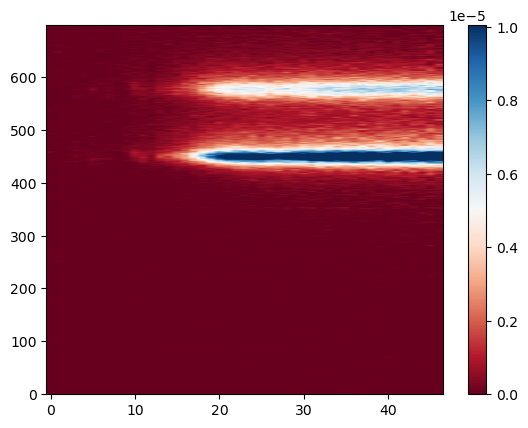

In [8]:

vmin, vmax = np.percentile(out_norm, [0,99])
plt.imshow(out_norm.T,vmin=vmin,vmax=vmax,origin='lower',aspect='auto',cmap='RdBu')
plt.colorbar()

In [9]:
diff=out_norm_laser-out_norm

In [14]:
diff=diff.T

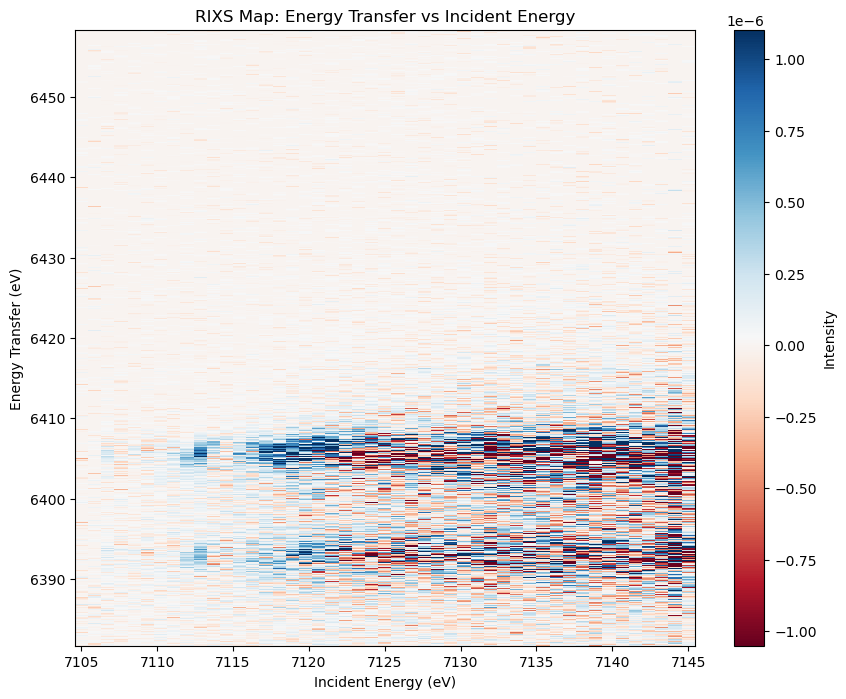

In [26]:
incident_energy = np.linspace(7105, 7145, diff.shape[1])  # keV -> eV
emission_energy = np.linspace(6200, 6450, diff.shape[0])  # eV
emission_energy=make_energy_axis(diff.shape[0],A=44,R=250)[::-1]
X, Y = np.meshgrid(incident_energy, emission_energy)


vmin, vmax = np.percentile(diff, [1, 99])

plt.figure(figsize=(10, 8))
plt.pcolormesh(X, Y, diff, vmin=vmin, vmax=vmax, cmap='RdBu', shading='auto')
plt.colorbar(label='Intensity')
plt.xlabel('Incident Energy (eV)')
plt.ylabel('Energy Transfer (eV)')
plt.title('RIXS Map: Energy Transfer vs Incident Energy')
plt.show()



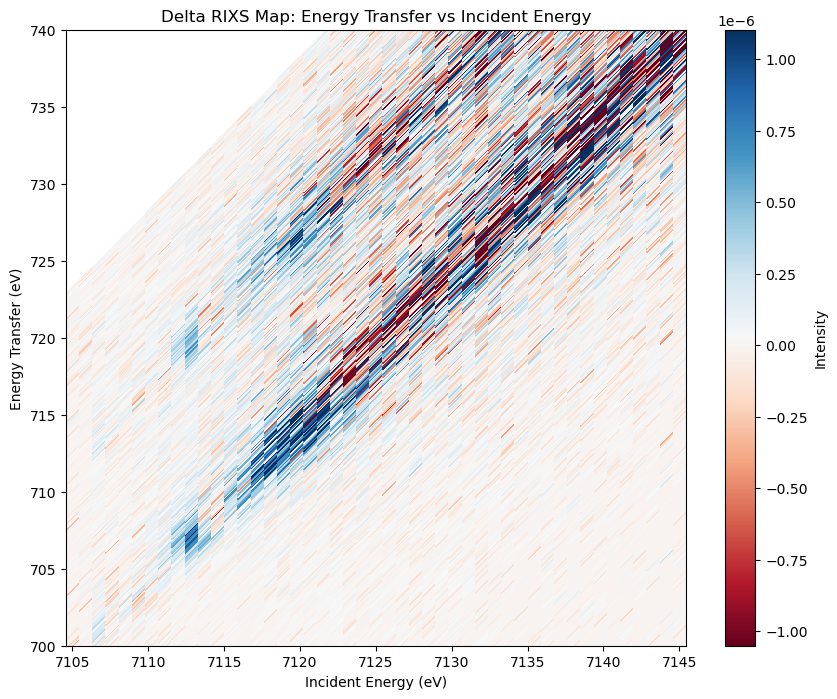

In [38]:
import numpy as np
import matplotlib.pyplot as plt
#diff=diff.T
# Your original data ranges
incident_energy = np.linspace(7105, 7145, diff.shape[1])  # keV -> eV
emission_energy = np.linspace(6200, 6450, diff.shape[0])  # eV
emission_energy=make_energy_axis(diff.shape[0],A=44,R=250,d=0.9809768044165565)[::-1]
# Convert incident energy to eV for consistency
incident_energy_eV = incident_energy #* 1000  # Convert keV to eV

# Create meshgrids
X, Y = np.meshgrid(incident_energy_eV, emission_energy)

# Calculate energy transfer
energy_transfer = X - Y

vmin, vmax = np.percentile(diff, [1, 99])

plt.figure(figsize=(10, 8))
plt.pcolormesh(X, energy_transfer, diff, vmin=vmin, vmax=vmax, cmap='RdBu', shading='auto')
plt.colorbar(label='Intensity')
plt.xlabel('Incident Energy (eV)')
plt.ylabel('Energy Transfer (eV)')
plt.title('Delta RIXS Map: Energy Transfer vs Incident Energy')
plt.ylim(700,740)
plt.show()

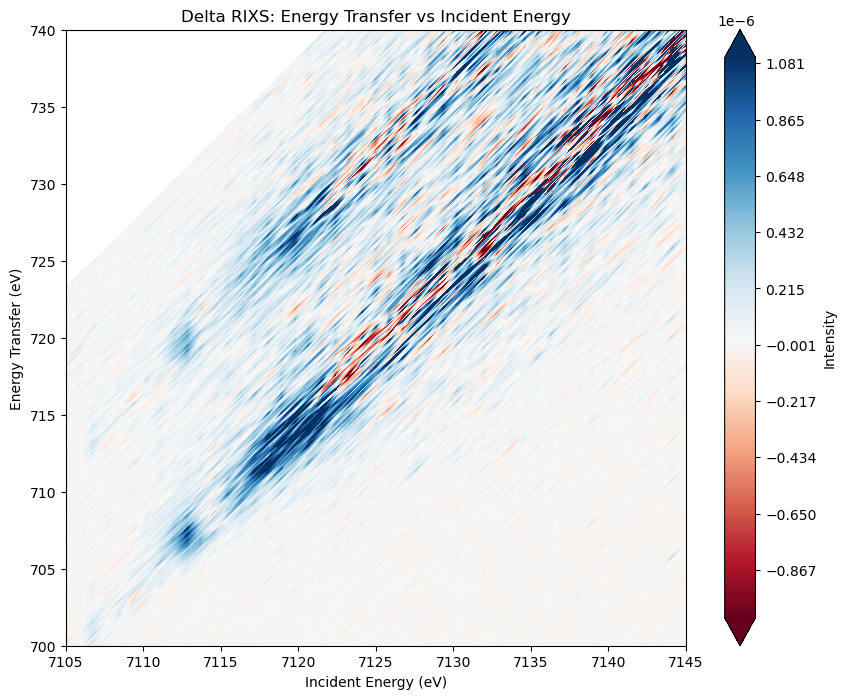

In [47]:
plt.figure(figsize=(10, 8))
levels = np.linspace(vmin, vmax, 200)
contour = plt.contourf(X, energy_transfer, diff, levels=levels, cmap='RdBu', extend='both')
plt.colorbar(contour, label='Intensity')
plt.xlabel('Incident Energy (eV)')
plt.ylabel('Energy Transfer (eV)')
plt.title('Delta RIXS: Energy Transfer vs Incident Energy')
plt.ylim(700,740)
plt.show()

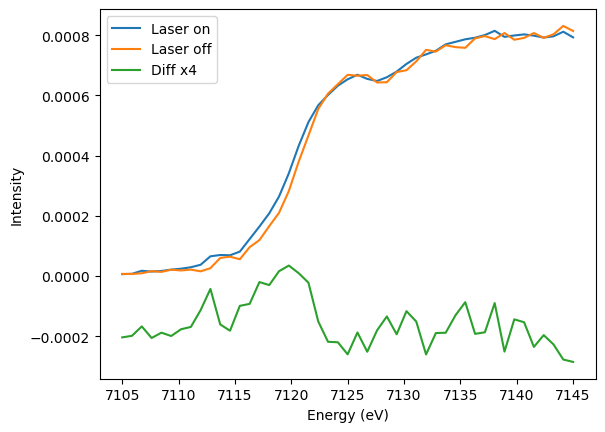

In [57]:
plt.plot(incident_energy,np.nansum(out_norm_laser,axis=1))
plt.plot(incident_energy,np.nansum(out_norm,axis=1))
plt.plot(incident_energy,(np.nansum(out_norm_laser,axis=1)-np.nansum(out_norm,axis=1))*4-2E-4)
plt.xlabel('Energy (eV)')
plt.ylabel('Intensity')
plt.legend(['Laser on','Laser off','Diff x4'])

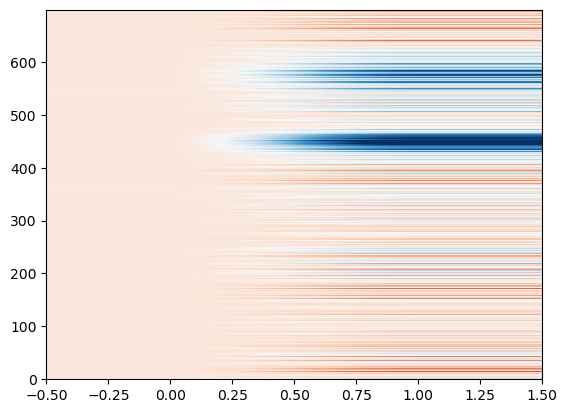

In [350]:
rixs=np.divide(out_bins,out_bins_ipm[:, np.newaxis])
rixs_laser=np.divide(out_bins_laser,out_bins_ipm_laser[:, np.newaxis])
vmin, vmax = np.percentile(out_bins, [0,99])
plt.imshow(out_bins.T,vmin=vmin,vmax=vmax,origin='lower',aspect='auto',cmap='RdBu')
#run_number='262_263'
#np.savetxt(f'rixs_10040_run_{run_number}.xy',rixs)
#np.savetxt(f'rixs_10040_laser_run_{run_number}.xy',rixs_laser)
#np.savetxt(f'rixs_10040_run_{run_number}.xy',rixs)
#np.savetxt(f'rixs_10040_laser_run_{run_number}.xy',rixs_laser)

In [349]:
np.shape(out_bins)

(2, 700)

In [ ]:

ind=int(np.shape(hf['epix_1/full_area'])[0]/2.0)

In [4]:
epix=np.array(hf['epix_1/full_area'][ind:-1])

In [4]:
epix=np.array(hf['epix_1/full_area'][ind:-1])

In [4]:
epix=np.array(hf['epix_1/full_area'][ind:-1])

In [5]:
hf['scan'].keys()

<KeysViewHDF5 ['DCCM_energy_with_vernier', 'var0']>

In [6]:
dccm=np.array(hf['scan/DCCM_energy_with_vernier'][ind:-1])

In [7]:
ipm=np.array(hf['ipm_dg1/sum'][ind:-1])

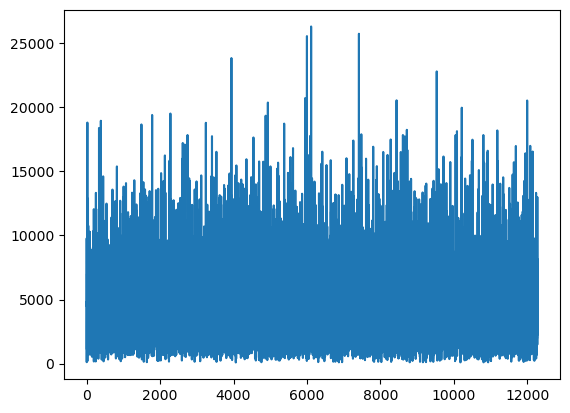

In [8]:
plt.plot(ipm)

In [9]:
images=filter_detector_adu(epix,adu_threshold=3.0)
unique_energies = np.unique(dccm)
energy_values=dccm
n_energies = len(unique_energies)

# Initialize output array
summed_images = np.zeros((n_energies, images.shape[1], images.shape[2]))
summed_ipm=np.zeros((n_energies))
counts = np.zeros(n_energies, dtype=int)

for i, energy in enumerate(unique_energies):
    mask = energy_values == energy
    summed_images[i] = np.nansum(images[mask], axis=0)
    summed_ipm[i] = np.nansum(ipm[mask], axis=0)
    counts[i] = np.nansum(mask)


In [10]:
summed_images=np.divide(summed_images,summed_ipm[:, np.newaxis, np.newaxis])

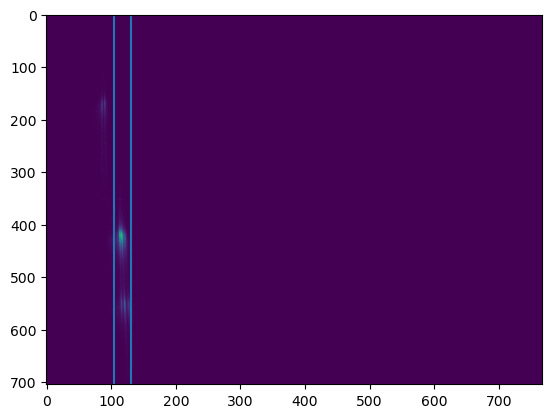

In [12]:
plt.imshow(np.nansum(summed_images,axis=0),aspect='auto')
plt.axvline(105)
plt.axvline(130)

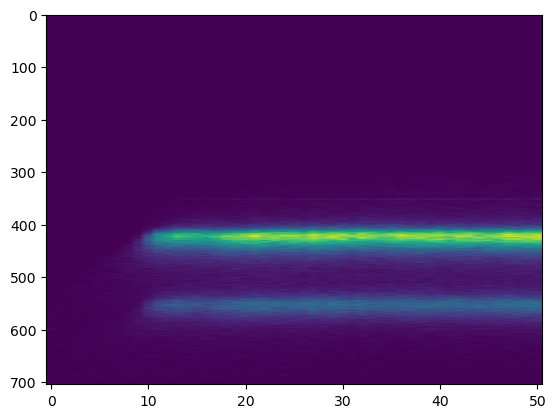

In [13]:
xes_energies=np.linspace(6380,6415,np.shape(summed_images)[1])

plt.imshow(np.transpose(np.nansum(summed_images[:,:,105:130],axis=2)),aspect='auto')

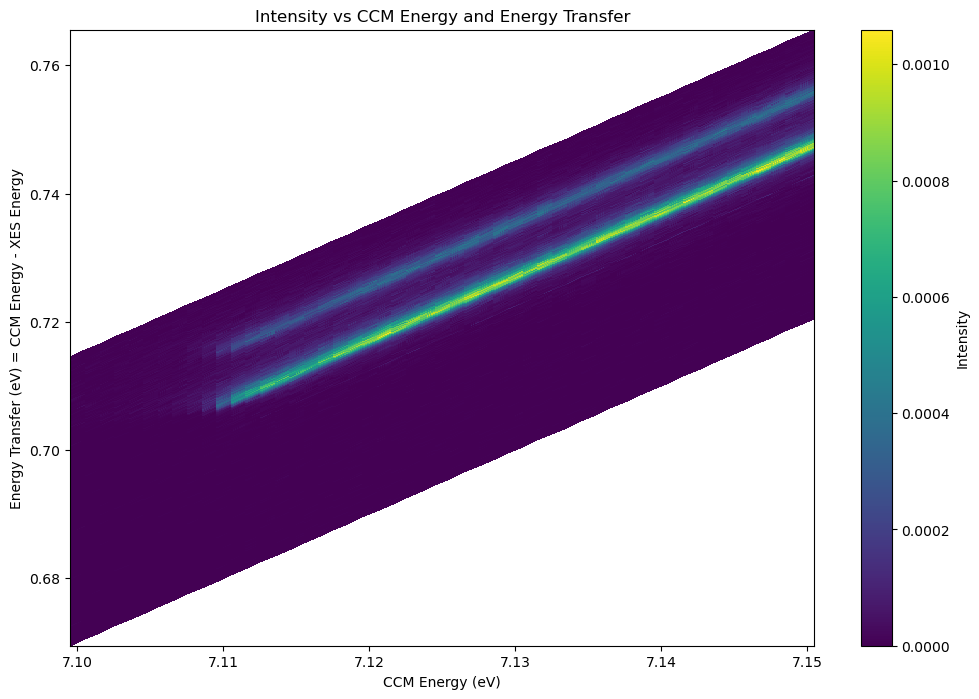

In [14]:
xes_energies = np.linspace(6.430, 6.385, np.shape(summed_images)[1])
data = np.transpose(np.nansum(summed_images[:,:,105:130], axis=2))

# Create meshgrid for CCM energies and XES energies
CCM_grid, XES_grid = np.meshgrid(unique_energies, xes_energies)

# Calculate energy transfer = CCM energy - XES energy
energy_transfer = CCM_grid - XES_grid

plt.figure(figsize=(12, 8))
plt.pcolormesh(CCM_grid, energy_transfer, data, shading='auto', cmap='viridis')
plt.xlabel('CCM Energy (eV)')
plt.ylabel('Energy Transfer (eV) = CCM Energy - XES Energy')
plt.colorbar(label='Intensity')
plt.title('Intensity vs CCM Energy and Energy Transfer')
#plt.ylim(6.390,6.410)
plt.show()

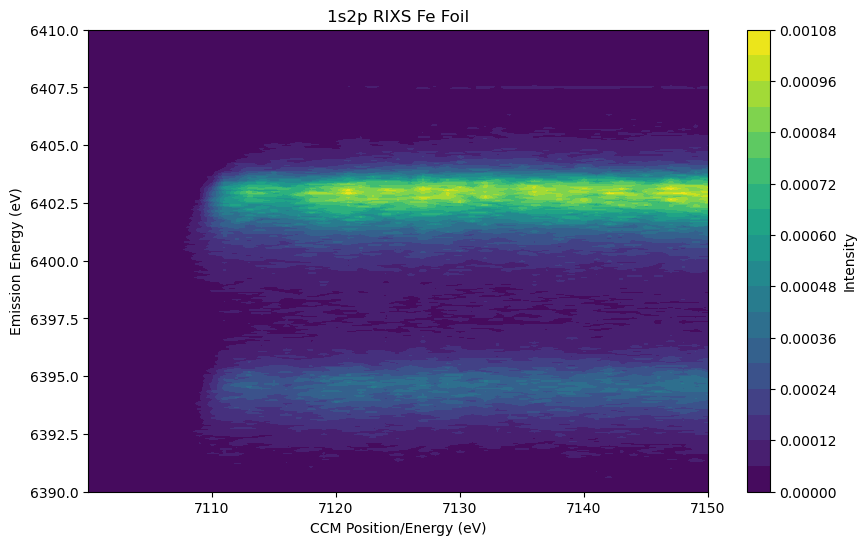

In [22]:
xes_energies = np.linspace(6430, 6385, np.shape(summed_images)[1])
X, Y = np.meshgrid(unique_energies*1000.0, xes_energies)
data = np.transpose(np.nansum(summed_images[:,:,105:130], axis=2))

plt.figure(figsize=(10, 6))
contour = plt.contourf(X, Y, data, levels=20, cmap='viridis')
plt.xlabel('CCM Position/Energy (eV)')
plt.ylabel('Emission Energy (eV)')
plt.colorbar(contour, label='Intensity')
plt.title('1s2p RIXS Fe Foil')
plt.ylim(6390,6410)
plt.show()

Text(0.5, 1.0, 'HERFD XAS - Fe Foil')

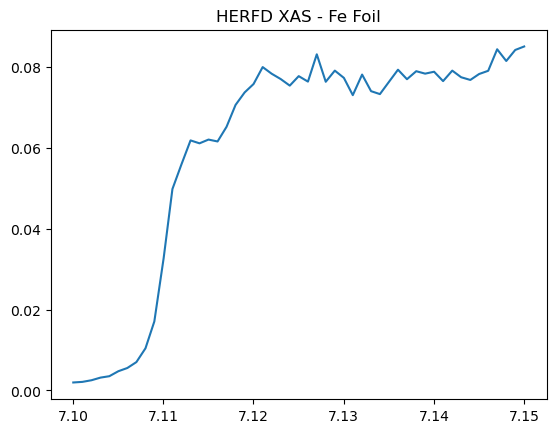

In [16]:
xas=np.nansum(np.nansum(summed_images,axis=2),axis=1)
plt.plot(unique_energies, xas)
plt.title('HERFD XAS - Fe Foil')

Text(0.5, 1.0, 'Calibration +1.2 eV')

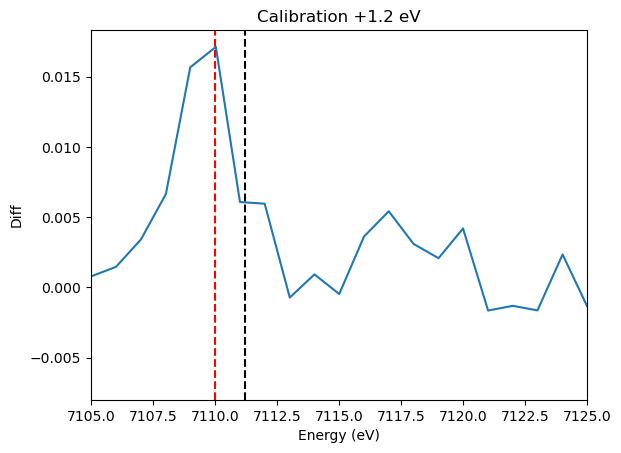

In [34]:
plt.plot(unique_energies[:-1]*1000.0,np.diff(xas))
plt.xlim([7105,7125])
plt.axvline(7111.2,color='k',linestyle='--')
plt.axvline(7110,color='r',linestyle='--')
plt.ylabel('Diff')
plt.xlabel('Energy (eV)')
plt.title('Calibration +1.2 eV')
#print(7.1112-7.110)

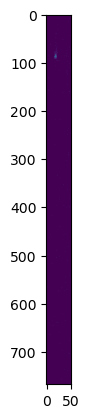

In [31]:
plt.imshow(np.transpose(np.nansum(summed_images[:,70:99,:],axis=1)))
#plt.axvline(70)
#plt.axvline(99)

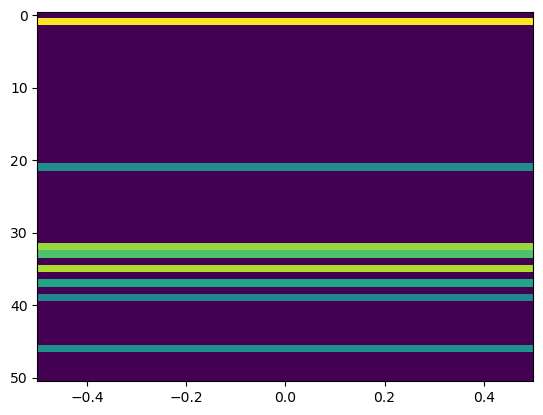

In [24]:
plt.imshow(np.nansum(summed_images[:,:70:99],axis=2),aspect='auto')
#plt.axvline(70)
#plt.axvline(99)

# List out all of the keys on the top level of the hierarchical data structure.

In [6]:
epix=np.array(hf['epix100_1/ROI_area'])

In [7]:
epix_summed=np.sum(epix,axis=0)

In [8]:
epix_filtered=filter_detector_adu(epix,adu_threshold=3)
epix_sum_filtered=np.sum(epix_filtered,axis=0)

Text(0.5, 1.0, 'Run 34')

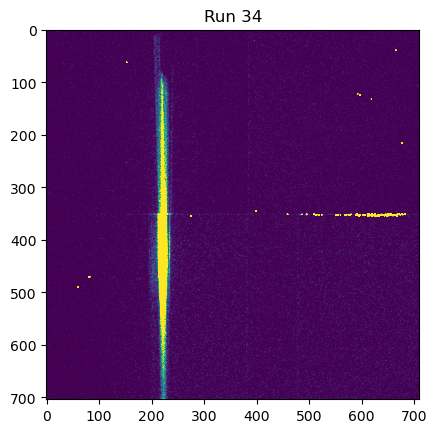

In [18]:

vmin, vmax = np.percentile(epix_sum_filtered, [1, 99])
plt.imshow(epix_sum_filtered, vmin=vmin, vmax=vmax)
plt.title('Run 34')

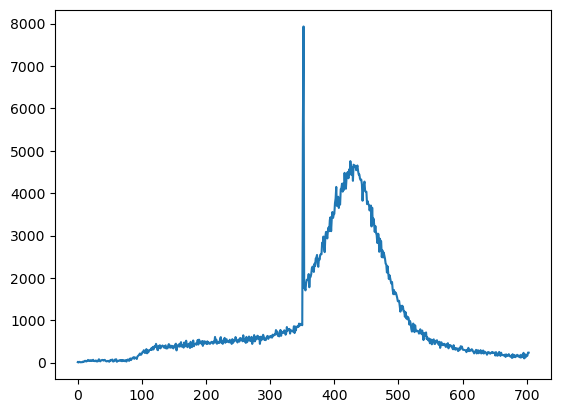

In [19]:
plt.plot(np.nansum(epix_sum_filtered[:,200:250],axis=1))

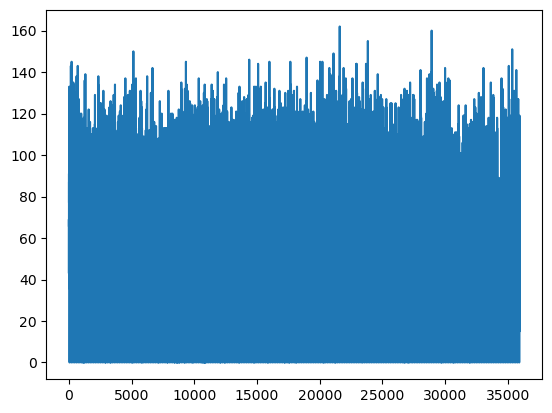

In [3]:
plt.plot(np.array(hf['epix_1/droplet_nDroplets_all']))

In [7]:
det_name='epix_1'
col = np.array(hf[f"{det_name}/var_full_sparse/col"])
row = np.array(hf[f"{det_name}/var_full_sparse/row"])
adu = np.array(hf[f"{det_name}/var_droplet_sparse/data"])
n_droplets = len(adu)

# Additional thresholding.
adu_thr = [0, 15]
indices = np.where((adu >= adu_thr[0]) & (adu <= adu_thr[1]))

dimg, xedges, yedges = np.histogram2d(
    col[indices],
    row[indices],
    bins=[np.arange(760), np.arange(700)],
    weights=adu[indices],
)

(array([0., 0., 0., ..., 0., 0., 0.]),
 array([ 1.  ,  1.01,  1.02, ..., 20.07, 20.08, 20.09]),
 <BarContainer object of 1909 artists>)

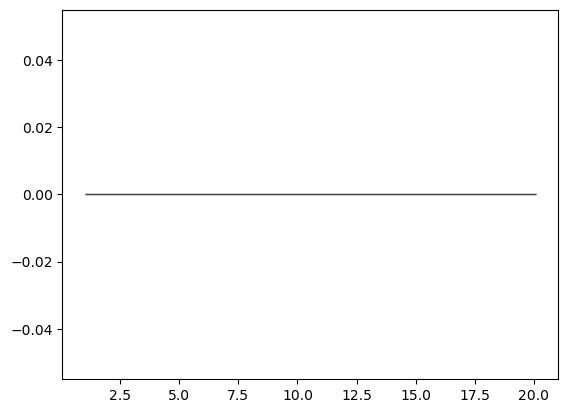

In [8]:
bins = np.arange(1, 20.1, 0.01)
plt.hist(adu, bins=bins, edgecolor='black')

In [7]:
np.shape(adu)

(2529890,)

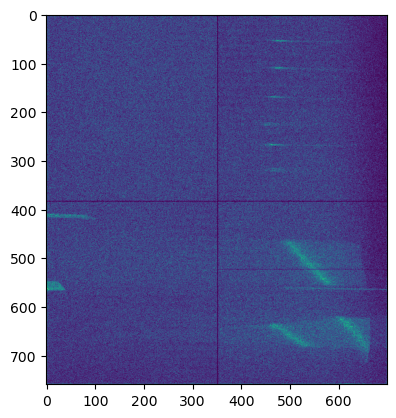

In [3]:
plt.imshow(dimg)


KeyboardInterrupt



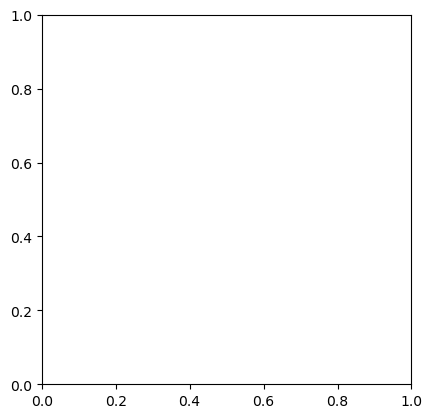

In [6]:
img=np.array(hf['epix_1/ROI_0_area'])
def filter_detector_adu(detector_images,adu_threshold=[3.0]):
    if isinstance(adu_threshold,list):
        detector_images_adu = detector_images * (detector_images > adu_threshold[0])
        detector_images_adu = detector_images * (detector_images < adu_threshold[1])
       
    else:
        detector_images_adu = detector_images * (detector_images > adu_threshold)
    return detector_images_adu
img=filter_detector_adu(np.nansum(img),adu_threshold=[2,15])
plt.imshow(img)

# The stored epics variables are under the epics key. These must be in the epics arch file. And in the small data producer. The line that looks like this:

epicsPV = [('LAS:FS45', 'lxt'),('MFX:LAS:MMN:06:delay:OphydReadback','txt')]

epicsPV = [
    ("MFX:TFS:MMS:21", "lens_z"),
    ("LAS:FS45:VIT:FS_TGT_TIME", "lxt_fs_tgt"),
    ("LAS:FS45:lxt:OphydReadback", "lxt"),
    ("MFX:LAS:MMN:06", "txt_mot"),  # txt
    ("MFX:LAS:MMN:06:delay:OphydReadback", "txt"),
    ("MFX:LAS:MMN:01:delay:OphydReadback", "lxt_fast"),
    ("MFX:LAS:MMN:01", "lxt_fast_mot"),
]


And possibly modify 

def mfxDetectors(beamCodes=[[-137], [204]], env=None):
    dets = []
    dets.append(lightStatus(codes=beamCodes))
    dets.append(controlDetector())
    dets.append(feeBldDetector("FEE-SPEC0", "feeBld"))
    dets.append(aiDetector("MFX-AIN-01", "ai"))
    dets.append(ttDetector(env=env))
    dets.append(bmmonDetector("MFX-DG1-BMMON", "ipm_dg1"))
    dets.append(bmmonDetector("MFX-DG2-BMMON", "ipm_dg2"))
    dets.append(damageDetector())
    dets.append(xtcavDetector("xtcav", "xtcav"))
    try:
        dets.append(encoderDetector("XRT-USB-ENCODER-01", "xrt_enc"))
        dets.append(encoderDetector("MFX-USB-ENCODER-01", "enc"))
    except:
        pass
    dets.append(
        epicsDetector(
            PVlist=[
                "atten_trans1",
                "atten_trans3",
                "fee_Attenuator_transmission",
                "lens_energy",
                "BeamMonitor_target",
                "Dg1Ipm_target",
                "lxt",
                "txt",
            ]
        )
    )
    return dets
in the hutch_defaults.py file. If they aren't in the epics arch I think they won't appear in the smalldata. 

In [9]:
hf['epics'].keys()

<KeysViewHDF5 ['BeamMonitor_target', 'Dg1Ipm_target', 'atten_trans1', 'atten_trans3', 'lens_energy', 'lens_z']>

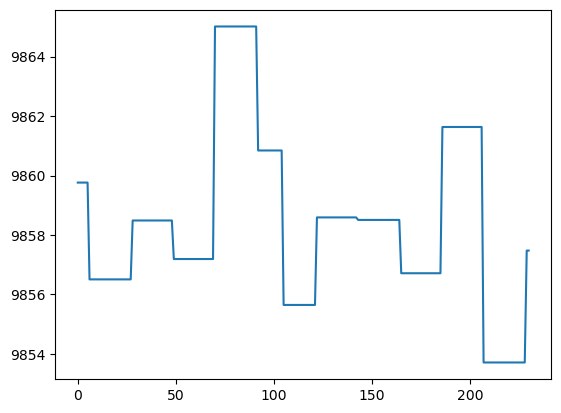

In [8]:
plt.plot(np.array(hf['epics/lens_energy']))

In [10]:
hf.keys()

<KeysViewHDF5 ['UserDataCfg', 'damage', 'ebeam', 'epics', 'epicsUser', 'event_time', 'evr', 'feeBld', 'fiducials', 'gas_detector', 'ipm_dg1', 'ipm_dg2', 'lightStatus']>

In [11]:
hf['epicsUser'].keys()

<KeysViewHDF5 ['ft_motor_sample_x', 'ft_motor_sample_y']>